In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

#Ignoring warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../DataSets/Loan_approval_data_2025.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [3]:
df.isnull().sum()
df.head(
)

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [4]:
numeric_cols = df.select_dtypes("number")
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
len(numeric_cols.columns)

16

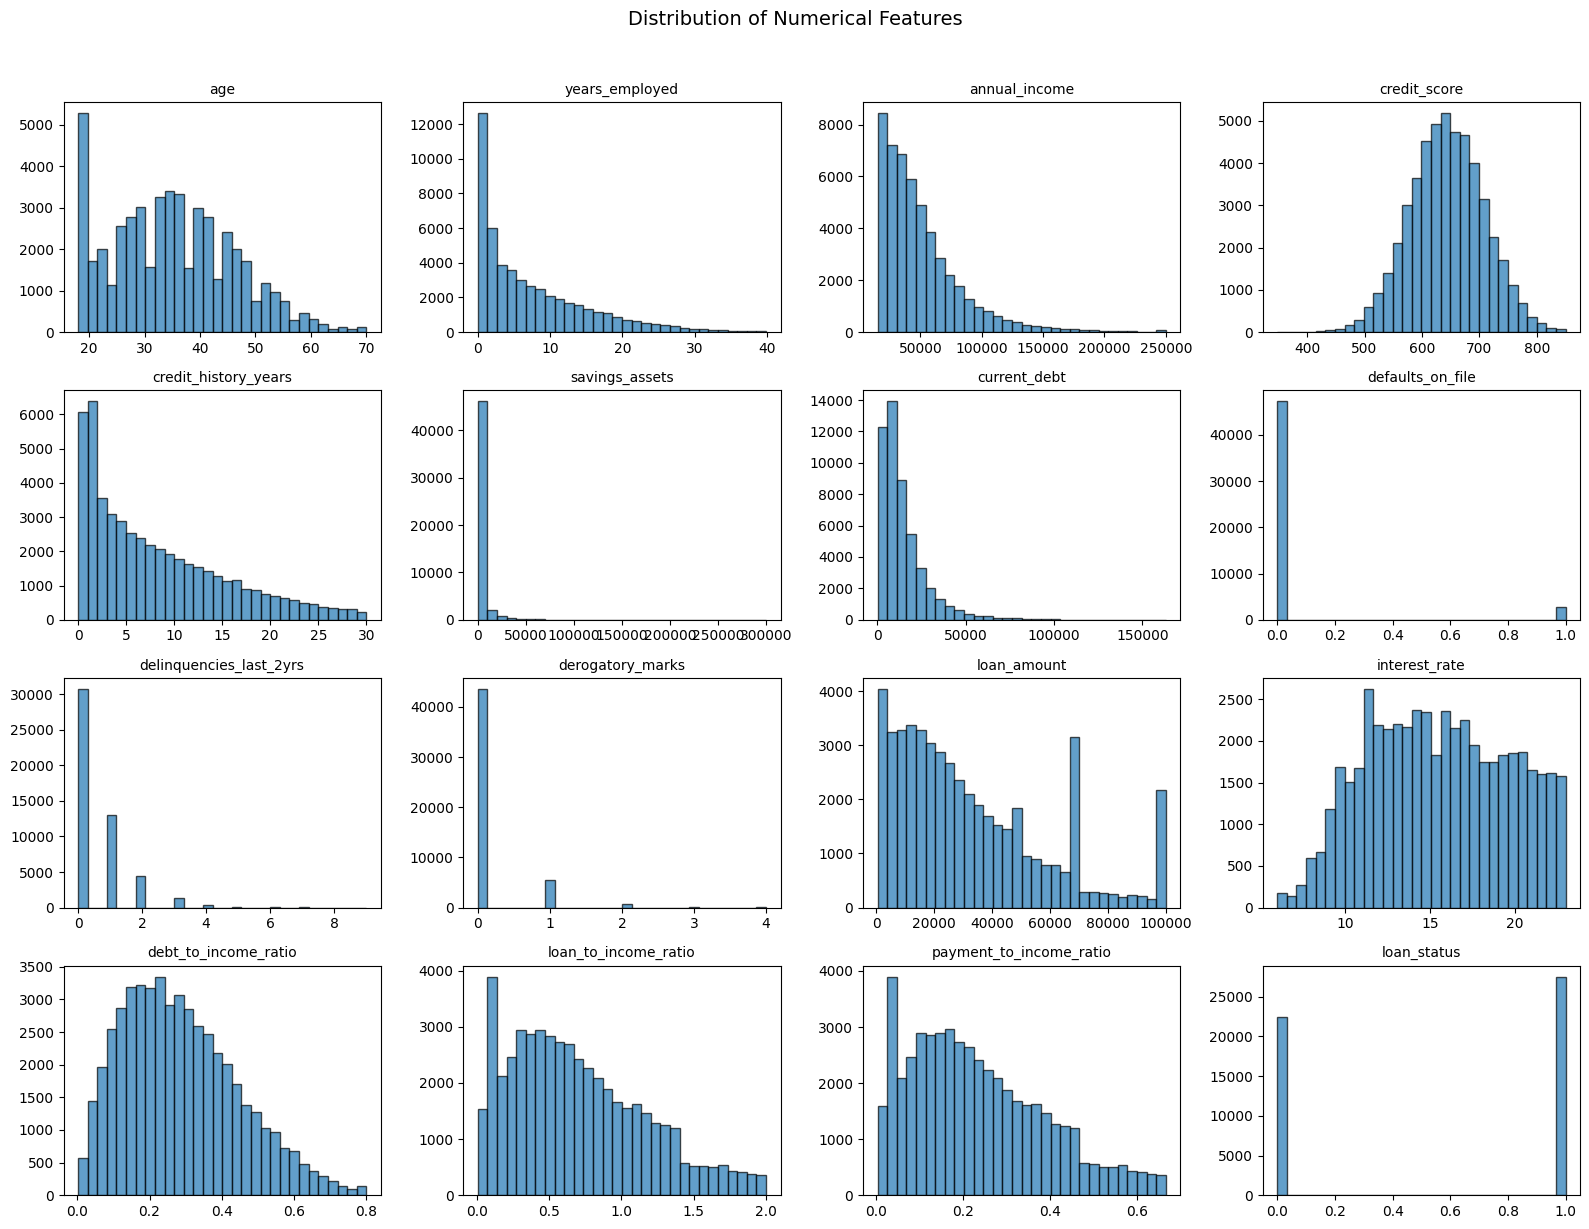

In [5]:
# Distribution of numerical features
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
# axes is a 4x4 array of subplots
# axes[0,0]  axes[0,1]  axes[0,2] axes[0,3]
# axes[1,0]  axes[1,1]  axes[1,2] ...
# ...

# To access each subplot, you need row and column indices:
# axes[0,0].plot(data1)
# axes[0,1].plot(data2)
# etc...
axes = axes.ravel()

for idx, col in enumerate(numeric_cols.columns):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel('')

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Turn categorical data into numerical
- occupation_status - ['Employed', 'Student', 'Self-Employed']
- product_type - ['Credit Card', 'Personal Loan', 'Line of Credit']
- loan_intent - ['Business', 'Home Improvement', 'Debt Consolidation', 'Education',
       'Personal', 'Medical']

In [6]:
category_features = df[["occupation_status", "product_type", "loan_intent"]]

occupation_dict = {"Employed" : 1,
                   "Student" : 2,
                   "Self-Employed" : 3}

product_dict = {"Credit Card" : 1,
                "Personal Loan" : 2,
                "Line of Credit" : 3}